In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv('weather_delay_binary.csv')
df.head(20)

,Unnamed: 0,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,...,et0_fao_evapotranspiration_DEST,sunrise_DEST,sunset_DEST,daylight_duration_DEST,sunshine_duration_DEST,precipitation_sum_DEST,rain_sum_DEST,snowfall_sum_DEST,precipitation_hours_DEST,WEATHER_DELAY_BINARY
0,0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,2.234588,0,0,35426.990,32053.1580,0.000000,0.000000,0.00,0.0,0
1,1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,2.234588,0,0,35426.990,32053.1580,0.000000,0.000000,0.00,0.0,0
2,2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,2.234588,0,0,35426.990,32053.1580,0.000000,0.000000,0.00,0.0,0
3,3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,...,1.506416,0,0,34233.156,30449.0940,0.000000,0.000000,0.00,0.0,0
4,4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,...,2.690572,0,0,38037.360,33106.9100,0.000000,0.000000,0.00,0.0,0
5,5,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,14100,PHL,"Philadelphia, PA",Pennsylvania,...,1.392567,0,0,33863.100,25166.6070,0.000000,0.000000,0.00,0.0,0
6,6,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10397,ATL,"Atlanta, GA",Georgia,...,1.792407,0,0,35896.180,32267.5700,0.000000,0.000000,0.00,0.0,0
7,7,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10397,ATL,"Atlanta, GA",Georgia,...,1.792407,0,0,35896.180,32267.5700,0.000000,0.000000,0.00,0.0,0
8,8,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10431,AVL,"Asheville, NC",North Carolina,...,1.553634,0,0,35339.562,31465.4500,0.000000,0.000000,0.00,0.0,0
9,9,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10431,AVL,"Asheville, NC",North Carolina,...,1.553634,0,0,35339.562,31465.4500,0.000000,0.000000,0.00,0.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9883 entries, 0 to 9882
Data columns (total 69 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          9883 non-null   int64  
 1   FL_DATE                             9883 non-null   object 
 2   ORIGIN_AIRPORT_ID                   9883 non-null   int64  
 3   ORIGIN                              9883 non-null   object 
 4   ORIGIN_CITY_NAME                    9883 non-null   object 
 5   ORIGIN_STATE_NM                     9883 non-null   object 
 6   DEST_AIRPORT_ID                     9883 non-null   int64  
 7   DEST                                9883 non-null   object 
 8   DEST_CITY_NAME                      9883 non-null   object 
 9   DEST_STATE_NM                       9883 non-null   object 
 10  DEP_DELAY_NEW                       9883 non-null   float64
 11  DEP_DEL15                           9883 no

**Predict whether a flight will be delayed**

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [6]:
df = df.drop(["DEP_DELAY_NEW", "ARR_DELAY_NEW", "ARR_DEL15", "WEATHER_DELAY"], axis=1)


y = df["WEATHER_DELAY_BINARY"]
X = df.drop(["WEATHER_DELAY_BINARY", "FL_DATE"], axis=1)

In [7]:
# this converts categorical values to "numerical" values using one hot encoding since logistic regression only works with numerical data
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.2f}")

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1934
           1       0.06      0.72      0.11        43

    accuracy                           0.73      1977
   macro avg       0.52      0.73      0.47      1977
weighted avg       0.97      0.73      0.83      1977

Logistic Regression Accuracy: 0.73


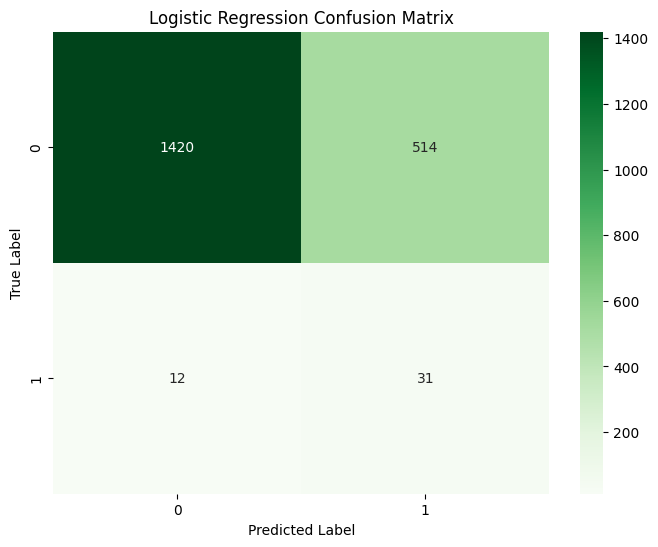

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

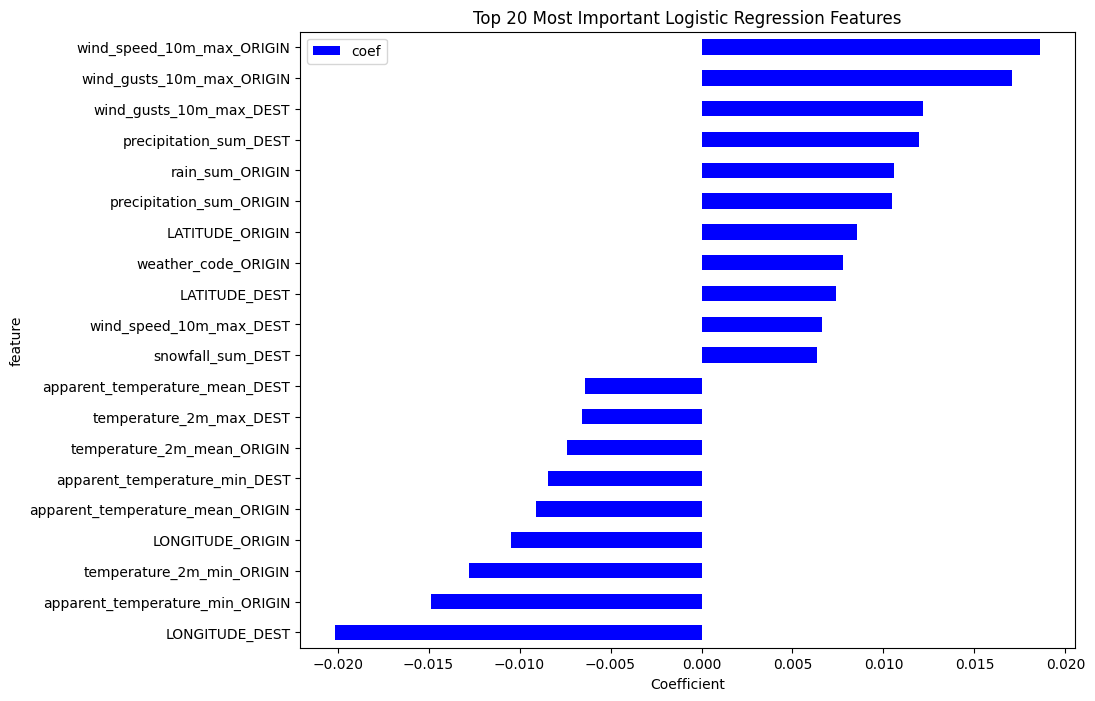

In [12]:
import numpy as np

# Coefficients
coefs = pd.DataFrame({
    "feature": X_train.columns,
    "coef": clf.coef_[0]
})

# Take absolute value for importance
coefs["importance"] = np.abs(coefs["coef"])

# Get top 20
top_coefs = coefs.sort_values("importance", ascending=False).head(20)

# Plot
top_coefs.sort_values("coef").plot(
    kind="barh", x="feature", y="coef", figsize=(10,8), color="blue"
)
plt.xlabel("Coefficient")
plt.title("Top 20 Most Important Logistic Regression Features")
plt.show()


In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7906, 591)
(1977, 591)
(7906,)
(1977,)


In [14]:
# checking for overffitting or underfitting. To find out whether your model is generalizing well to unseen data or not.
# comparing the training data and testing data together.

#train accuracy : How well your model performs on the data it was trained on (X_train, y_train)
#test accuracy : How well your model performs on new, unseen data (X_test, y_test)
print("Train Accuracy:", clf.score(X_train, y_train))
print("Test Accuracy:", clf.score(X_test, y_test))

Train Accuracy: 0.7288135593220338
Test Accuracy: 0.7339403136064745


**Initially the dataset is imbalanced meaning that once class has way more data compared to other ones. This means there is not enough varied data. In our case, for our target variable "DEP_DEL15", there might be an huge amount of delayed flights (1) but a small amount of on-time flights (0), or vice-versa. So after first round of training, the training and test accuracy as well as model accuracy is quite low:**

- Train Accuracy: 0.5717516964061322
- Test Accuracy: 0.5859296482412061
- Logistic Regression Accuracy: 0.50

**Decision Tree Classifier**

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
y_pred_dt = dt_model.predict(X_test)

**Find accuracy score**

In [21]:
print('Accuracy Score:', metrics.accuracy_score(y_test, y_pred_dt))

Accuracy Score: 0.9615579160343956


**Confusion Matrix**

In [22]:
print(metrics.confusion_matrix(y_test, y_pred_dt)) 

[[1889   45]
 [  31   12]]


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rd = rf_model.predict(X_test)

Random Forest Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1934
           1       0.28      0.21      0.24        43

    accuracy                           0.97      1977
   macro avg       0.63      0.60      0.61      1977
weighted avg       0.97      0.97      0.97      1977



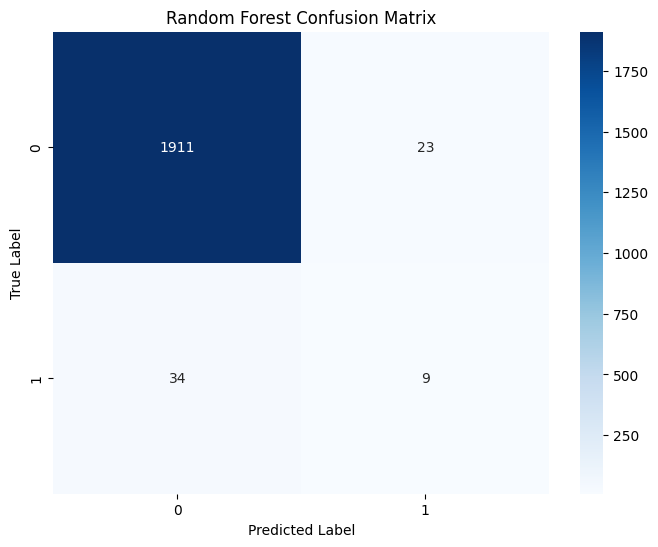

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred_rd)
print(f"Random Forest Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_rd))

cm = confusion_matrix(y_test, y_pred_rd)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [27]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9711684370257967


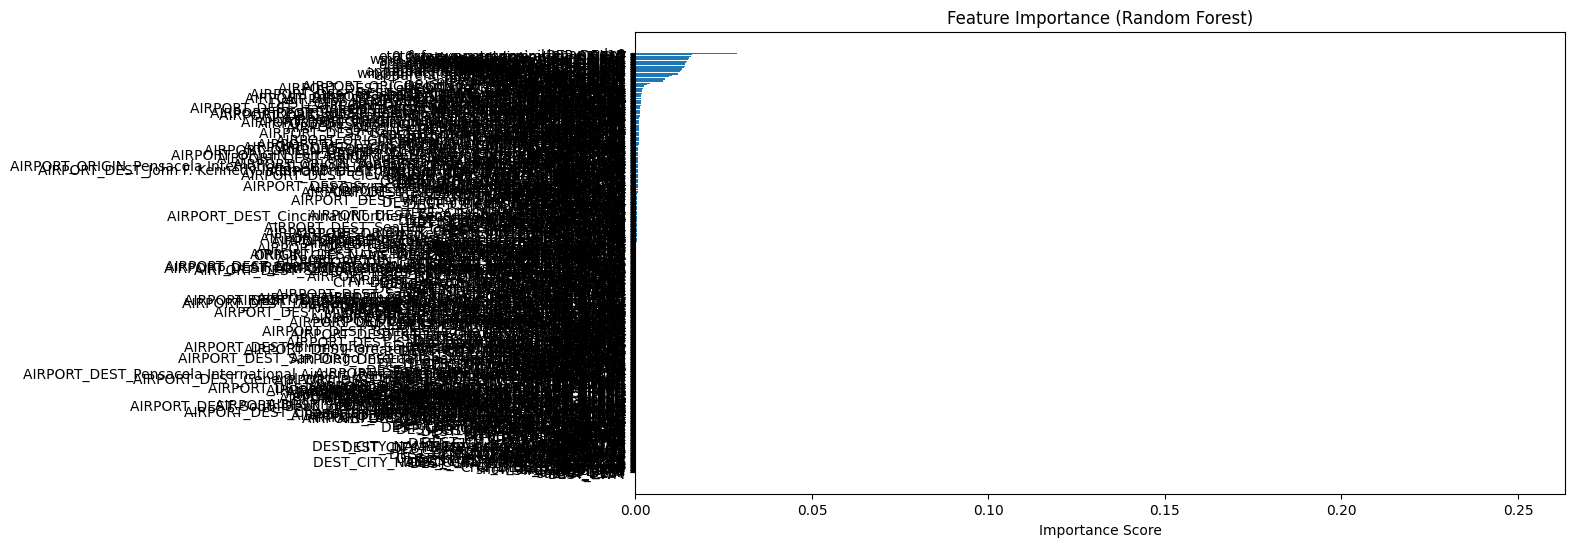

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({'feature': feature_names,'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Feature Importance (Random Forest)")
plt.show()